In [ ]:
# 1. Import function
import sys
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import keras
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import svm
from sklearn import tree
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
import sklearn.metrics
import seaborn as sns
from sklearn.metrics import accuracy_score
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# 2. Baca data
print("Membaca Data =================================================================")
data = pd.read_csv("covid-liver.csv", encoding='latin1')
df = pd.DataFrame(data)
print(df)

Membaca Data =================================================================
    Cancer         Year  Month Bleed Mode_Presentation  Age Gender Etiology  \
0        Y  Prepandemic      1     N      Surveillance   68      M    NAFLD   
1        Y  Prepandemic      1     N      Surveillance   70      M     ARLD   
2        Y  Prepandemic      1     N      Surveillance   64      M     ARLD   
3        Y  Prepandemic      1     N        Incidental   73      M     ARLD   
4        Y  Prepandemic      1     N        Incidental   66      F     ARLD   
..     ...          ...    ...   ...               ...  ...    ...      ...   
445      N     Pandemic     12   NaN       Symptomatic   72      F      NaN   
446      N     Pandemic     12   NaN       Symptomatic   63      M      NaN   
447      N     Pandemic     12   NaN       Symptomatic   79      F      NaN   
448      N     Pandemic     12   NaN       Symptomatic   84      F      NaN   
449      N     Pandemic     12   NaN        Incident

In [ ]:
# 3. Mengambil varibel
print("\nMengambil Variabel ================================================================")
# Menggunakan replace() untuk mengubah nilai kategori menjadi nilai numerik
df["Cancer"] = df["Cancer"].replace({
    "Y": 1,  # Change Y to 1 (assuming Y represents presence of cancer)
    "N": 0,  # Change N to 0 (assuming N represents absence of cancer)
})
print(df)

Month = df["Month"]
print(Month)

Age = df["Age"]
print(Age)

Size = df["Size"]
print(Size)

Survival = df["Survival_fromMDM"]
print(Survival)

Diagnosis = df["Time_diagnosis_1st_Tx"]
print(Diagnosis)

PS = df["PS"]
print(PS)

Time_MDM = df["Time_MDM_1st_treatment"]
print(Time_MDM)

Time_Decision = df["Time_decisiontotreat_1st_treatment"]
print(Time_Decision)

Months_Surveillance = df["Months_from_last_surveillance"]
print(Months_Surveillance)

# Tanpa data kategori (hanya data numerik)
selected_columns = df.iloc[:, [2, 5, 9, 14, 20, 22, 23, 24, 26]]
print(selected_columns)


Mengambil Variabel ================================================================
     Cancer         Year  Month Bleed Mode_Presentation  Age Gender Etiology  \
0         1  Prepandemic      1     N      Surveillance   68      M    NAFLD   
1         1  Prepandemic      1     N      Surveillance   70      M     ARLD   
2         1  Prepandemic      1     N      Surveillance   64      M     ARLD   
3         1  Prepandemic      1     N        Incidental   73      M     ARLD   
4         1  Prepandemic      1     N        Incidental   66      F     ARLD   
..      ...          ...    ...   ...               ...  ...    ...      ...   
445       0     Pandemic     12   NaN       Symptomatic   72      F      NaN   
446       0     Pandemic     12   NaN       Symptomatic   63      M      NaN   
447       0     Pandemic     12   NaN       Symptomatic   79      F      NaN   
448       0     Pandemic     12   NaN       Symptomatic   84      F      NaN   
449       0     Pandemic     12   N

In [ ]:
# 4. Deteksi missing value\
print("\nDeteksi missing value ================================")
missing_values = df.isnull().sum()

# Menampilkan variabel yang memiliki missing value
variables_with_missing_values = missing_values[missing_values > 0].index.tolist()
print("Variabel yang memiliki missing value:")
print(variables_with_missing_values)


Deteksi missing value ================================
Variabel yang memiliki missing value:
['Bleed', 'Etiology', 'Cirrhosis', 'Size', 'HCC_TNM_Stage', 'HCC_BCLC_Stage', 'ICC_TNM_Stage', 'Treatment_grps', 'Type_of_incidental_finding', 'Surveillance_programme', 'Surveillance_effectiveness', 'Mode_of_surveillance_detection', 'Time_diagnosis_1st_Tx', 'Date_incident_surveillance_scan', 'PS', 'Time_MDM_1st_treatment', 'Time_decisiontotreat_1st_treatment', 'Prev_known_cirrhosis', 'Months_from_last_surveillance']


In [ ]:
# 5a. Mengganti missing value dalam kolom Size dengan nilai rata-rata
print("\nMengganti missing value dalam kolom Size dengan nilai rata-rata")
# Langkah 1
df_Size = df
# Langkah 2
rata_Size = df_Size["Size"].mean()
# Langkah 3
df_Size["Size"] = df_Size["Size"].fillna(rata_Size)
# Langkah 4
df_Size["Size"].isna().sum()
print(df_Size["Size"])

# 5b. Mengganti missing value dalam kolom Time Diagnosis dengan nilai rata-rata
print("\nMengganti missing value dalam kolom Time Diagnosis dengan nilai rata-rata")
# Langkah 1
df_time_diagnosis = df
# Langkah 2
rata_time_diagnosis = df_Size["Time_diagnosis_1st_Tx"].mean()
# Langkah 3
df_time_diagnosis["Time_diagnosis_1st_Tx"] = df_time_diagnosis["Time_diagnosis_1st_Tx"].fillna(rata_time_diagnosis)
# Langkah 4
df_time_diagnosis["Time_diagnosis_1st_Tx"].isna().sum()
print(df_time_diagnosis["Time_diagnosis_1st_Tx"])

# 5c. Mengganti missing value dalam kolom Time MDM dengan nilai rata-rata
print("\nMengganti missing value dalam kolom Time MDM dengan nilai rata-rata")
# Langkah 1
df_time_mdm = df
# Langkah 2
rata_time_mdm = df_Size["Time_MDM_1st_treatment"].mean()
# Langkah 3
df_time_mdm["Time_MDM_1st_treatment"] = df_time_mdm["Time_MDM_1st_treatment"].fillna(rata_time_mdm)
# Langkah 4
df_time_mdm["Time_MDM_1st_treatment"].isna().sum()
print(df_time_mdm["Time_MDM_1st_treatment"])

# 5d. Mengganti missing value dalam kolom Time Decision to Treat dengan nilai rata-rata
print("\nMengganti missing value dalam kolom Time Decision to Treat dengan nilai rata-rata")
# Langkah 1
df_time_decision_to_treat = df
# Langkah 2
rata_time_decision_to_treat = df_time_decision_to_treat["Time_decisiontotreat_1st_treatment"].mean()
# Langkah 3
df_time_decision_to_treat["Time_decisiontotreat_1st_treatment"] = df_time_decision_to_treat["Time_decisiontotreat_1st_treatment"].fillna(rata_time_decision_to_treat)
# Langkah 4
df_time_decision_to_treat["Time_decisiontotreat_1st_treatment"].isna().sum()
print(df_time_decision_to_treat["Time_decisiontotreat_1st_treatment"])

# 5e. Mengganti missing value dalam kolom Months from Last Surveillance dengan nilai rata-rata
print("\nMengganti missing value dalam kolom Months from Last Surveillance dengan nilai rata-rata")
# Langkah 1
df_months = df
# Langkah 2
rata_months = df_months["Months_from_last_surveillance"].mean()
# Langkah 3
df_months["Months_from_last_surveillance"] = df_months["Months_from_last_surveillance"].fillna(rata_months)
# Langkah 4
df_months["Months_from_last_surveillance"].isna().sum()
print(df_months["Months_from_last_surveillance"])

# 5f. Mengganti missing value dalam kolom Survical dengan nilai rata-rata
print("\nMengganti missing value dalam kolom Survical dengan nilai rata-rata")
# Langkah 1
df_survival = df
# Langkah 2
rata_survival = df_survival["Survival_fromMDM"].mean()
# Langkah 3
df_survival["Survival_fromMDM"] = df_survival["Survival_fromMDM"].fillna(rata_months)
# Langkah 4
df_survival["Survival_fromMDM"].isna().sum()
print(df_survival["Survival_fromMDM"])


Mengganti missing value dalam kolom Size dengan nilai rata-rata
0      22.000
1      40.000
2      52.000
3      80.000
4      60.000
        ...  
445    53.355
446    75.000
447    63.000
448    65.000
449    45.000
Name: Size, Length: 450, dtype: float64

Mengganti missing value dalam kolom Time Diagnosis dengan nilai rata-rata
0      0.47000
1     -6.57038
2     -6.57038
3     -6.57038
4     -6.57038
        ...   
445   -6.57038
446    2.93000
447   -6.57038
448   -6.57038
449    0.00000
Name: Time_diagnosis_1st_Tx, Length: 450, dtype: float64

Mengganti missing value dalam kolom Time MDM dengan nilai rata-rata
0      0.700000
1      2.385988
2      2.385988
3      2.385988
4      2.385988
         ...   
445    2.385988
446    1.630000
447    2.385988
448    2.385988
449    2.385988
Name: Time_MDM_1st_treatment, Length: 450, dtype: float64

Mengganti missing value dalam kolom Time Decision to Treat dengan nilai rata-rata
0      1.500841
1      1.500841
2      1.500841
3      1.5

In [ ]:
# 6. Outlier
print("\nOutlier =================================================================")
def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers

# Deteksi outlier untuk setiap kolom dalam selected_columns
outliers_dict = {}
for col in selected_columns.columns:
    outliers_dict[col] = detect_outliers_iqr(selected_columns[col])

# Menampilkan outlier untuk setiap kolom
for col, outliers in outliers_dict.items():
    print(f"\nOutliers for column '{col}':")
    print(outliers)



Outlier =================================================================

Outliers for column 'Month':
Series([], Name: Month, dtype: int64)

Outliers for column 'Age':
46     43
53     41
123    44
192    45
235    35
290    27
291    41
346    28
382    39
384    44
388    39
414    39
Name: Age, dtype: int64

Outliers for column 'Size':
13     150.0
32     150.0
108    150.0
145    150.0
150    200.0
193    210.0
198    150.0
225    150.0
264    220.0
267    200.0
284    210.0
291    170.0
294    150.0
298    220.0
301    220.0
304    150.0
329    190.0
379    190.0
426    150.0
Name: Size, dtype: float64

Outliers for column 'Survival_fromMDM':
Series([], Name: Survival_fromMDM, dtype: float64)

Outliers for column 'Time_diagnosis_1st_Tx':
14       12.53
53       13.57
84        6.30
113       8.40
121       9.23
134      13.03
156       6.17
340   -1434.07
345       7.00
389      12.60
Name: Time_diagnosis_1st_Tx, dtype: float64

Outliers for column 'PS':
Series([], Name: PS, dt

In [ ]:
# 7. Mengatasi Outlier
print("\nMengatasi Outlier =================================================================")
# Definisikan DataFrame selected_columns
selected_columns = df.iloc[:, [9, 20, 23, 24, 26]]  # Perbaiki indeks kolom Time Decision

# Fungsi untuk mendeteksi outlier menggunakan IQR
def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers

# Fungsi untuk menangani outliers dengan menggantinya dengan nilai batas atas/bawah
def handle_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    column = column.mask(column < lower_bound, lower_bound)
    column = column.mask(column > upper_bound, upper_bound)
    return column

# Deteksi outlier untuk setiap kolom dalam selected_columns
outliers_dict = {}
for col in selected_columns.columns:
    outliers_dict[col] = detect_outliers_iqr(selected_columns[col])

# Menampilkan outlier untuk setiap kolom
for col, outliers in outliers_dict.items():
    print(f"\nOutliers for column '{col}':")
    print(outliers)

# Penanganan outliers dengan menggantikan nilai outlier dengan batas atas/bawah
cleaned_selected_columns = selected_columns.copy()
for col in selected_columns.columns:
    cleaned_selected_columns[col] = handle_outliers(selected_columns[col])

# Menampilkan data setelah penanganan outliers
print("\nData setelah penanganan outliers:")
print(cleaned_selected_columns)


Mengatasi Outlier =================================================================

Outliers for column 'Size':
13     150.0
32     150.0
63     130.0
108    150.0
145    150.0
150    200.0
159    133.0
193    210.0
198    150.0
225    150.0
264    220.0
267    200.0
284    210.0
289    140.0
291    170.0
294    150.0
298    220.0
299    130.0
301    220.0
304    150.0
329    190.0
330    135.0
379    190.0
426    150.0
Name: Size, dtype: float64

Outliers for column 'Time_diagnosis_1st_Tx':
53       13.57
340   -1434.07
Name: Time_diagnosis_1st_Tx, dtype: float64

Outliers for column 'Time_MDM_1st_treatment':
0      0.70
6      3.00
7      1.40
8      1.53
10     2.70
       ... 
432    1.83
433    1.37
438    0.67
439    0.70
446    1.63
Name: Time_MDM_1st_treatment, Length: 162, dtype: float64

Outliers for column 'Time_decisiontotreat_1st_treatment':
8      0.80
15     0.23
18     1.20
19     0.23
28     2.07
       ... 
432    1.83
433    1.37
438    0.67
439    0.70
446    1.63

In [ ]:
# 8. Normalisasi Data
print("\nNormalisasi Data =================================================================")
data_norm = cleaned_selected_columns
df = pd.DataFrame(data_norm)
min_max_scaler = preprocessing.MinMaxScaler()
np_scaled = min_max_scaler.fit_transform(df)
df_normalized = pd.DataFrame(np_scaled)
print(f"\nData setelah normalisasi: ",df_normalized)


Normalisasi Data =================================================================

Data setelah normalisasi:              0         1    2    3    4
0    0.101053  0.598635  0.0  0.0  0.0
1    0.252632  0.375000  0.0  0.0  0.0
2    0.353684  0.375000  0.0  0.0  0.0
3    0.589474  0.375000  0.0  0.0  0.0
4    0.421053  0.375000  0.0  0.0  0.0
..        ...       ...  ...  ...  ...
445  0.365095  0.375000  0.0  0.0  0.0
446  0.547368  0.676776  0.0  0.0  0.0
447  0.446316  0.375000  0.0  0.0  0.0
448  0.463158  0.375000  0.0  0.0  0.0
449  0.294737  0.583706  0.0  0.0  0.0

[450 rows x 5 columns]



 Klasifikasi debgan Seleksi Fitur =================================================================

 a. PCA


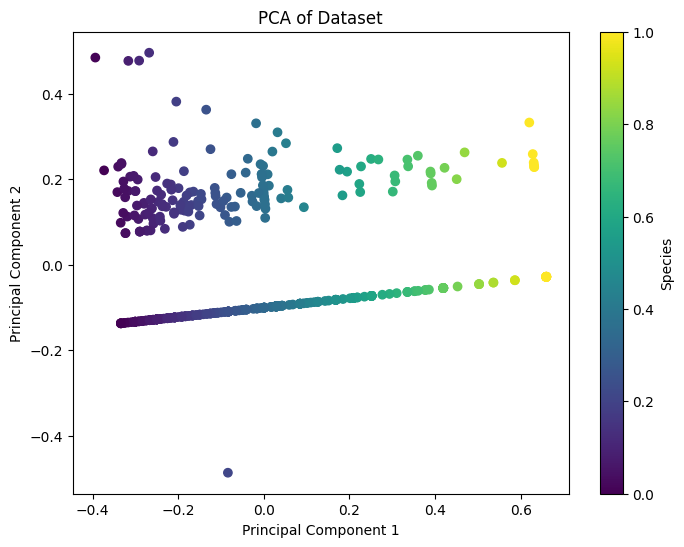

Naïve Bayes Performance:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00        12

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



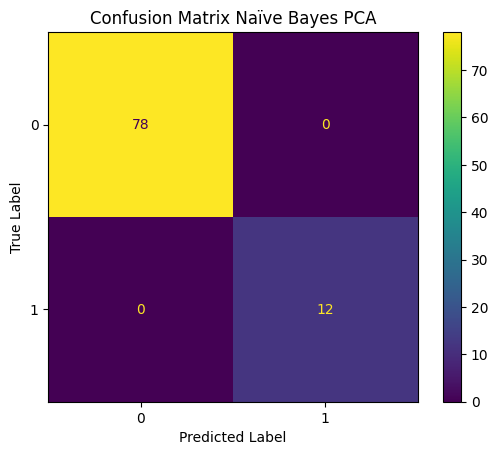

SVM Performance:
Accuracy: 0.9888888888888889
Precision: 0.9936708860759493
Recall: 0.9583333333333333
F1 Score: 0.9750761561894212
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        78
           1       1.00      0.92      0.96        12

    accuracy                           0.99        90
   macro avg       0.99      0.96      0.98        90
weighted avg       0.99      0.99      0.99        90



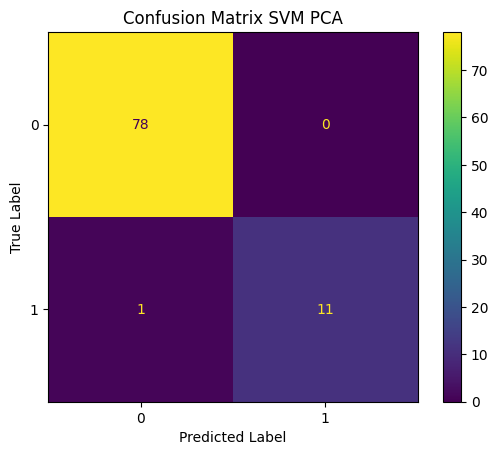

KNN Performance:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        78
           1       1.00      1.00      1.00        12

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



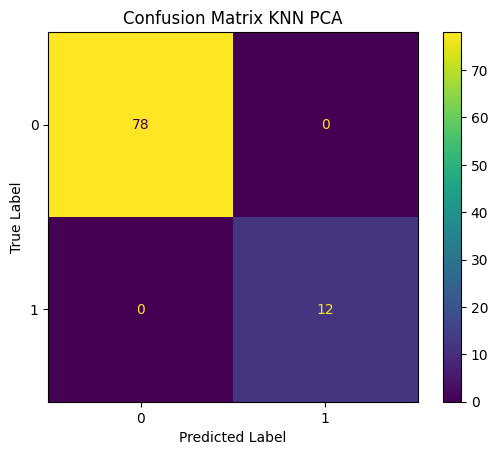

Epoch 1/50
12/12 [==============================] - 1s 3ms/step - loss: 0.6796 - accuracy: 0.5972
Epoch 2/50
12/12 [==============================] - 0s 3ms/step - loss: 0.6295 - accuracy: 0.7389
Epoch 3/50
12/12 [==============================] - 0s 3ms/step - loss: 0.5856 - accuracy: 0.7667
Epoch 4/50
12/12 [==============================] - 0s 3ms/step - loss: 0.5358 - accuracy: 0.7806
Epoch 5/50
12/12 [==============================] - 0s 3ms/step - loss: 0.4860 - accuracy: 0.8083
Epoch 6/50
12/12 [==============================] - 0s 3ms/step - loss: 0.4306 - accuracy: 0.8528
Epoch 7/50
12/12 [==============================] - 0s 4ms/step - loss: 0.3790 - accuracy: 0.8750
Epoch 8/50
12/12 [==============================] - 0s 3ms/step - loss: 0.3311 - accuracy: 0.8889
Epoch 9/50
12/12 [==============================] - 0s 3ms/step - loss: 0.2886 - accuracy: 0.9583
Epoch 10/50
12/12 [==============================] - 0s 3ms/step - loss: 0.2498 - accuracy: 0.9500
Epoch 11/50
12/12 [

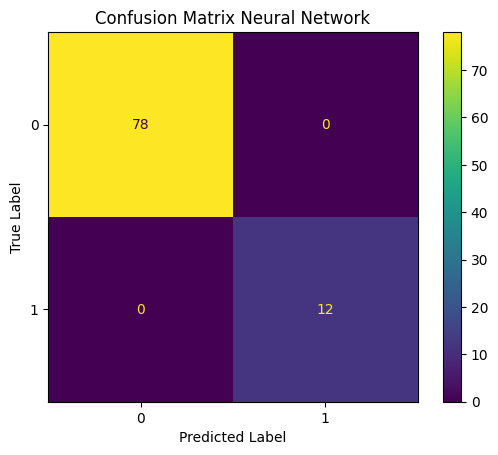

In [ ]:
# 9. Klasifikasi dengan Seleksi Fitur
print("\n Klasifikasi debgan Seleksi Fitur =================================================================")

# a. PCA
print("\n a. PCA")
# Load dataset
X = df_normalized.iloc[:, 0:4]
y = df_normalized[0]

# Apply PCA
pca = PCA(n_components=2)  # Menentukan jumlah komponen yang diinginkan
X_pca = pca.fit_transform(X)

# Plot hasil PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Dataset')
plt.colorbar(label='Species')
plt.show()

# Klasifikasi Naive Bayes PCA
X = df_normalized.iloc[:, 0:4]
# Mengubah label numerik menjadi kategori biner (0 dan 1)
y = np.where(y > 0.5, 1, 0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Initialize and train Naïve Bayes classifier
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

# Predict using the trained classifier
nb_y_pred = nb_classifier.predict(X_test)

# Evaluate Naïve Bayes performance
print("Naïve Bayes Performance:")
print("Accuracy:", accuracy_score(y_test, nb_y_pred))
print("Precision:", precision_score(y_test, nb_y_pred, average='macro'))
print("Recall:", recall_score(y_test, nb_y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, nb_y_pred, average='macro'))
print(classification_report(y_test, nb_y_pred))

# Visualize Confusion Matrix Naïve Bayes
cm_nb = confusion_matrix(y_test, nb_y_pred)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=np.unique(y))
disp_nb.plot()
plt.title("Confusion Matrix Naïve Bayes PCA")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Klasifikasi SVM PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
X = df_normalized.iloc[:, 2:9]
# Mengubah label numerik menjadi kategori biner (0 dan 1)
y = np.where(y > 0.5, 1, 0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Initialize and train SVM classifier
svm_classifier = SVC(kernel='linear')  # Gunakan kernel yang sesuai dengan data Anda
svm_classifier.fit(X_train, y_train)

# Predict using the trained classifier
svm_y_pred = svm_classifier.predict(X_test)

# Evaluate SVM performance
print("SVM Performance:")
print("Accuracy:", accuracy_score(y_test, svm_y_pred))
print("Precision:", precision_score(y_test, svm_y_pred, average='macro'))
print("Recall:", recall_score(y_test, svm_y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, svm_y_pred, average='macro'))
print(classification_report(y_test, svm_y_pred))

# Visualize Confusion Matrix SVM
cm_svm = confusion_matrix(y_test, svm_y_pred)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=np.unique(y))
disp_svm.plot()
plt.title("Confusion Matrix SVM PCA")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#Klasifikasi KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
X = df_normalized.iloc[:, 2:9]
# Mengubah label numerik menjadi kategori biner (0 dan 1)
y = np.where(y > 0.5, 1, 0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Initialize and train KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)  # Sesuaikan jumlah tetangga yang diinginkan
knn_classifier.fit(X_train, y_train)

# Predict using the trained classifier
knn_y_pred = knn_classifier.predict(X_test)

# Evaluate KNN performance
print("KNN Performance:")
print("Accuracy:", accuracy_score(y_test, knn_y_pred))
print("Precision:", precision_score(y_test, knn_y_pred, average='macro'))
print("Recall:", recall_score(y_test, knn_y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, knn_y_pred, average='macro'))
print(classification_report(y_test, knn_y_pred))

# Visualize Confusion Matrix KNN
cm_knn = confusion_matrix(y_test, knn_y_pred)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=np.unique(y))
disp_knn.plot()
plt.title("Confusion Matrix KNN PCA")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Load dataset
X = df_normalized.iloc[:, 0:4]
# Mengubah label numerik menjadi kategori biner (0 dan 1)
y = np.where(y > 0.5, 1, 0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and build the Neural Network model
model = Sequential()
model.add(Dense(100, input_dim=4, activation='relu'))  # Jumlah neuron di layer tersembunyi bisa disesuaikan (misal: 100)
model.add(Dense(50, activation='relu'))  # Jumlah neuron di layer tersembunyi bisa disesuaikan (misal: 50)
model.add(Dense(1, activation='sigmoid'))  # Layer output untuk klasifikasi biner

# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

# Predict using the trained model
nn_y_prob = model.predict(X_test)
nn_y_pred = (nn_y_prob > 0.5).astype(int)  # Menggunakan threshold 0.5 untuk mendapatkan prediksi biner

# Evaluate Neural Network performance
print("Neural Network Performance:")
print("Accuracy:", accuracy_score(y_test, nn_y_pred))
print("Precision:", precision_score(y_test, nn_y_pred, average='macro'))
print("Recall:", recall_score(y_test, nn_y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, nn_y_pred, average='macro'))
print(classification_report(y_test, nn_y_pred))

# Visualize Confusion Matrix Neural Network
cm_nn = confusion_matrix(y_test, nn_y_pred)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=np.unique(y))
disp_nn.plot()
plt.title("Confusion Matrix Neural Network")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


b. Chi Squared
(450, 2)
[[0.10105263157894738 '0']
 [0.25263157894736843 '1']
 [0.35368421052631577 '1']
 [0.5894736842105263 '2']
 [0.4210526315789474 '2']
 [0.11789473684210526 '0']
 [0.15157894736842104 '0']
 [0.2947368421052632 '1']
 [0.1936842105263158 '0']
 [0.5894736842105263 '2']
 [0.7578947368421052 '3']
 [0.1431578947368421 '0']
 [0.07578947368421053 '0']
 [1.0 '4']
 [0.10947368421052632 '0']
 [0.25263157894736843 '1']
 [0.07578947368421053 '0']
 [0.3705263157894737 '1']
 [0.8421052631578947 '4']
 [0.03368421052631579 '0']
 [0.37894736842105264 '1']
 [0.008421052631578954 '0']
 [0.16842105263157897 '0']
 [0.10105263157894738 '0']
 [0.6736842105263158 '3']
 [0.5052631578947367 '2']
 [0.15157894736842104 '0']
 [0.2947368421052632 '1']
 [0.08421052631578947 '0']
 [0.11789473684210526 '0']
 [0.28631578947368425 '1']
 [0.5052631578947367 '2']
 [1.0 '4']
 [0.25263157894736843 '1']
 [0.05052631578947368 '0']
 [0.36509473684210525 '1']
 [0.21052631578947367 '1']
 [0.0842105263157894

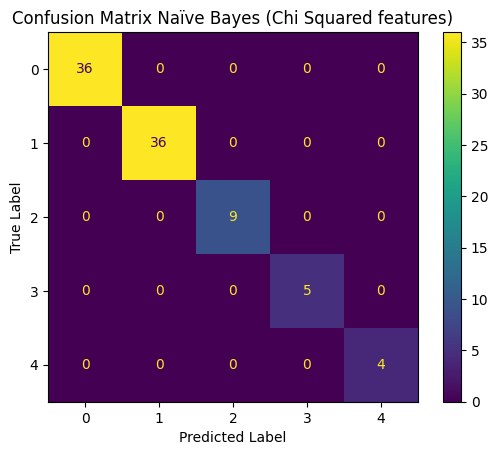

SVM Performance (Chi Squared features):
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00         9
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         4

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



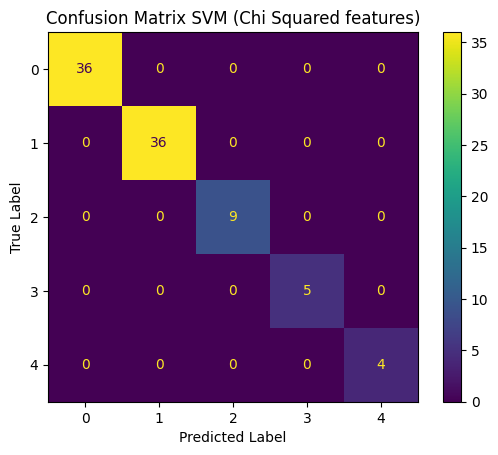

KNN Performance (Chi Squared features):
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00         9
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         4

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



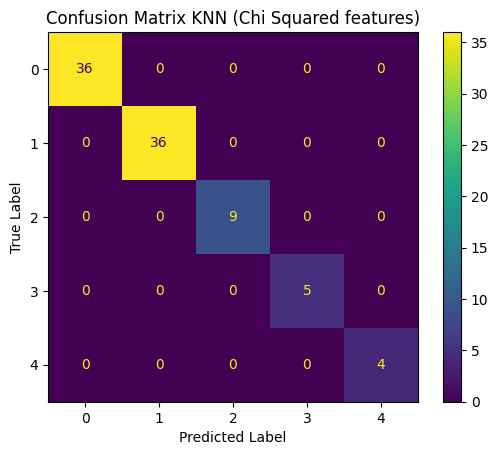

Epoch 1/50
12/12 [==============================] - 1s 3ms/step - loss: 1.5148 - accuracy: 0.4917
Epoch 2/50
12/12 [==============================] - 0s 3ms/step - loss: 1.2617 - accuracy: 0.5361
Epoch 3/50
12/12 [==============================] - 0s 2ms/step - loss: 1.0541 - accuracy: 0.4583
Epoch 4/50
12/12 [==============================] - 0s 2ms/step - loss: 0.8960 - accuracy: 0.5556
Epoch 5/50
12/12 [==============================] - 0s 3ms/step - loss: 0.7768 - accuracy: 0.6694
Epoch 6/50
12/12 [==============================] - 0s 3ms/step - loss: 0.6682 - accuracy: 0.7833
Epoch 7/50
12/12 [==============================] - 0s 3ms/step - loss: 0.5712 - accuracy: 0.8861
Epoch 8/50
12/12 [==============================] - 0s 3ms/step - loss: 0.4779 - accuracy: 0.9111
Epoch 9/50
12/12 [==============================] - 0s 3ms/step - loss: 0.4008 - accuracy: 0.9333
Epoch 10/50
12/12 [==============================] - 0s 2ms/step - loss: 0.3316 - accuracy: 0.9167
Epoch 11/50
12/12 [

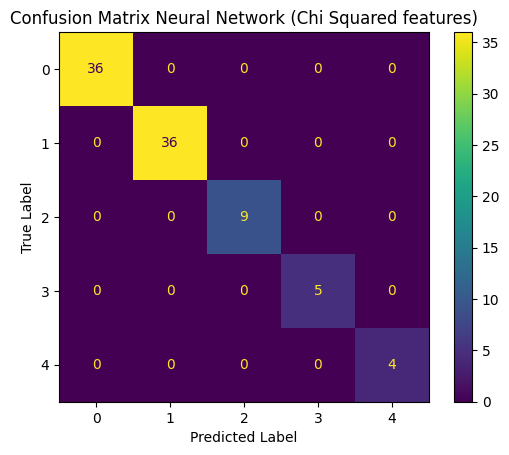

In [ ]:
# b. Chi Squared
print("\nb. Chi Squared")

df_normalized['label_Cancer'] = pd.cut(df_normalized[0], bins=5, labels=['0', '1', '2', '3', '4'])

# Ambil fitur dan label yang sudah diubah menjadi kategorikal
X = df_normalized.iloc[:, :27]
y = df_normalized['label_Cancer']
# Convert feature names to strings
X.columns = X.columns.astype(str)

# Apply SelectKBest class to extract top 2 best features
best_features = SelectKBest(score_func=chi2, k=2)
X_new = best_features.fit_transform(X, y)

# Show selected features
print(X_new.shape)
print(X_new)

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from keras.models import Sequential
from keras.layers import Dense

# Split data into training and testing sets for Chi Squared features
X_train_chi, X_test_chi, y_train_chi, y_test_chi = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Naïve Bayes Classifier
nb_classifier_chi = GaussianNB()
nb_classifier_chi.fit(X_train_chi, y_train_chi)
nb_y_pred_chi = nb_classifier_chi.predict(X_test_chi)

# Evaluate Naïve Bayes performance for Chi Squared features
print("Naïve Bayes Performance (Chi Squared features):")
print("Accuracy:", accuracy_score(y_test_chi, nb_y_pred_chi))
print("Precision:", precision_score(y_test_chi, nb_y_pred_chi, average='macro'))
print("Recall:", recall_score(y_test_chi, nb_y_pred_chi, average='macro'))
print("F1 Score:", f1_score(y_test_chi, nb_y_pred_chi, average='macro'))
print(classification_report(y_test_chi, nb_y_pred_chi))

# Visualize Confusion Matrix Naïve Bayes for Chi Squared features
cm_nb_chi = confusion_matrix(y_test_chi, nb_y_pred_chi)
disp_nb_chi = ConfusionMatrixDisplay(confusion_matrix=cm_nb_chi, display_labels=np.unique(y))
disp_nb_chi.plot()
plt.title("Confusion Matrix Naïve Bayes (Chi Squared features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# SVM Classifier
svm_classifier_chi = SVC(kernel='linear')  # Use appropriate kernel for your data
svm_classifier_chi.fit(X_train_chi, y_train_chi)
svm_y_pred_chi = svm_classifier_chi.predict(X_test_chi)

# Evaluate SVM performance for Chi Squared features
print("SVM Performance (Chi Squared features):")
print("Accuracy:", accuracy_score(y_test_chi, svm_y_pred_chi))
print("Precision:", precision_score(y_test_chi, svm_y_pred_chi, average='macro'))
print("Recall:", recall_score(y_test_chi, svm_y_pred_chi, average='macro'))
print("F1 Score:", f1_score(y_test_chi, svm_y_pred_chi, average='macro'))
print(classification_report(y_test_chi, svm_y_pred_chi))

# Visualize Confusion Matrix SVM for Chi Squared features
cm_svm_chi = confusion_matrix(y_test_chi, svm_y_pred_chi)
disp_svm_chi = ConfusionMatrixDisplay(confusion_matrix=cm_svm_chi, display_labels=np.unique(y))
disp_svm_chi.plot()
plt.title("Confusion Matrix SVM (Chi Squared features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# KNN Classifier
knn_classifier_chi = KNeighborsClassifier(n_neighbors=5)  # Adjust the number of neighbors as desired
knn_classifier_chi.fit(X_train_chi, y_train_chi)
knn_y_pred_chi = knn_classifier_chi.predict(X_test_chi)

# Evaluate KNN performance for Chi Squared features
print("KNN Performance (Chi Squared features):")
print("Accuracy:", accuracy_score(y_test_chi, knn_y_pred_chi))
print("Precision:", precision_score(y_test_chi, knn_y_pred_chi, average='macro'))
print("Recall:", recall_score(y_test_chi, knn_y_pred_chi, average='macro'))
print("F1 Score:", f1_score(y_test_chi, knn_y_pred_chi, average='macro'))
print(classification_report(y_test_chi, knn_y_pred_chi))

# Visualize Confusion Matrix KNN for Chi Squared features
cm_knn_chi = confusion_matrix(y_test_chi, knn_y_pred_chi)
disp_knn_chi = ConfusionMatrixDisplay(confusion_matrix=cm_knn_chi, display_labels=np.unique(y))
disp_knn_chi.plot()
plt.title("Confusion Matrix KNN (Chi Squared features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Neural Network Classifier
from sklearn.preprocessing import StandardScaler
from keras.utils import to_categorical

# Assuming X_train_chi and X_test_chi contain numerical data
# If your data contains categorical features, encode them first
# Example: One-hot encoding for categorical features
# encoder = OneHotEncoder()
# X_train_chi_encoded = encoder.fit_transform(X_train_chi)
# X_test_chi_encoded = encoder.transform(X_test_chi)

# Standardize the data
scaler = StandardScaler()
X_train_chi_scaled = scaler.fit_transform(X_train_chi)
X_test_chi_scaled = scaler.transform(X_test_chi)

# Convert labels to categorical format
y_train_chi_categorical = to_categorical(y_train_chi)  # Assuming 5 classes
y_test_chi_categorical = to_categorical(y_test_chi)  # Assuming 5 classes

# Define and compile the model
model_chi = Sequential()
model_chi.add(Dense(100, input_dim=X_train_chi_scaled.shape[1], activation='relu'))
model_chi.add(Dense(50, activation='relu'))
model_chi.add(Dense(5, activation='softmax'))  # Output layer for 5 classes

model_chi.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model_chi.fit(X_train_chi_scaled, y_train_chi_categorical, epochs=50, batch_size=32, verbose=1)

# Predict using the trained model
nn_y_prob_chi = model_chi.predict(X_test_chi_scaled)
nn_y_pred_chi = np.argmax(nn_y_prob_chi, axis=1)  # Convert probabilities to class labels

# Evaluate Neural Network performance for Chi Squared features
print("Neural Network Performance (Chi Squared features):")
print("Accuracy:", accuracy_score(np.argmax(y_test_chi_categorical, axis=1), nn_y_pred_chi))
print("Precision:", precision_score(np.argmax(y_test_chi_categorical, axis=1), nn_y_pred_chi, average='macro'))
print("Recall:", recall_score(np.argmax(y_test_chi_categorical, axis=1), nn_y_pred_chi, average='macro'))
print("F1 Score:", f1_score(np.argmax(y_test_chi_categorical, axis=1), nn_y_pred_chi, average='macro'))
print(classification_report(np.argmax(y_test_chi_categorical, axis=1), nn_y_pred_chi))

# Visualize Confusion Matrix Neural Network for Chi Squared features
cm_nn_chi = confusion_matrix(np.argmax(y_test_chi_categorical, axis=1), nn_y_pred_chi)
disp_nn_chi = ConfusionMatrixDisplay(confusion_matrix=cm_nn_chi, display_labels=np.unique(y))
disp_nn_chi.plot()
plt.title("Confusion Matrix Neural Network (Chi Squared features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()